Imports and Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setup plotting style and directories
sns.set_theme(style="whitegrid")
os.makedirs('charts', exist_ok=True)
print("Libraries imported and charts directory created successfully!")

Libraries imported and charts directory created successfully!


Task 1 — Data Loading & Exploration

In [2]:
# Load the dataset
df = pd.read_csv('Housing.csv')

# Display the first 10 rows
print("--- First 10 Rows of the Dataset ---")
display(df.head(10))

# Dimensions of the dataset
print("\n--- Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Identify Target and Features
print("\n--- Target Variable ---")
print("Target: 'price'")
print("\n--- Initial Feature Columns ---")
print(list(df.columns.drop('price')))

# Check for missing values
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 10 Rows of the Dataset ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- Dataset Dimensions ---
Rows: 545, Columns: 13

--- Target Variable ---
Target: 'price'

--- Initial Feature Columns ---
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Missing Values Per Column ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Task 2 — Data Cleaning

In [4]:
# 1. Handle Missing Values
df = df.dropna() 

# 2. Remove Duplicates
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removed {duplicate_count} duplicate rows.")

# 3. One-Hot Encoding for Categorical Columns (Updated to prevent Pandas 4+ warnings)
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Apply one-hot encoding, dropping the first category to avoid multi-collinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n--- Cleaned & Encoded Dataset Preview ---")
display(df_encoded.head())

Removed 0 duplicate rows.
Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

--- Cleaned & Encoded Dataset Preview ---


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Task 3 — Model Building & Evaluation

In [5]:
# Separate Target (y) and Features (X)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Define evaluation helper function
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return mae, rmse, r2

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_mae, lr_rmse, lr_r2 = evaluate_model(lr_model, X_test, y_test)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_mae, rf_rmse, rf_r2 = evaluate_model(rf_model, X_test, y_test)

# Performance Comparison Table
metrics_summary = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R² Score'],
    'Linear Regression': [f"${lr_mae:,.2f}", f"${lr_rmse:,.2f}", f"{lr_r2:.4f}"],
    'Random Forest': [f"${rf_mae:,.2f}", f"${rf_rmse:,.2f}", f"{rf_r2:.4f}"]
})
display(metrics_summary)

Training set shape: (436, 13), Test set shape: (109, 13)


,Metric,Linear Regression,Random Forest
0,Mean Absolute Error (MAE),"$970,043.40","$1,021,546.04"
1,Root Mean Squared Error (RMSE),"$1,324,506.96","$1,400,565.97"
2,R² Score,0.6529,0.6119


Task 4 — Visualization

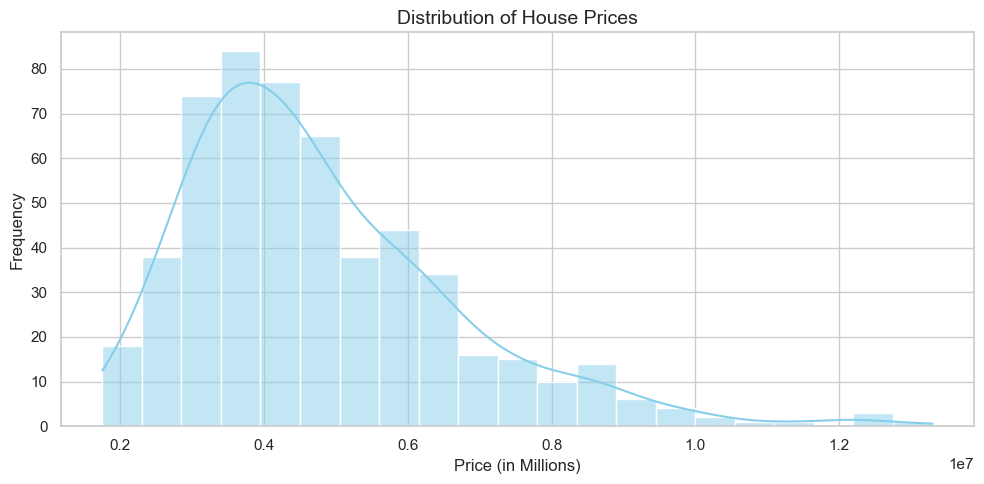

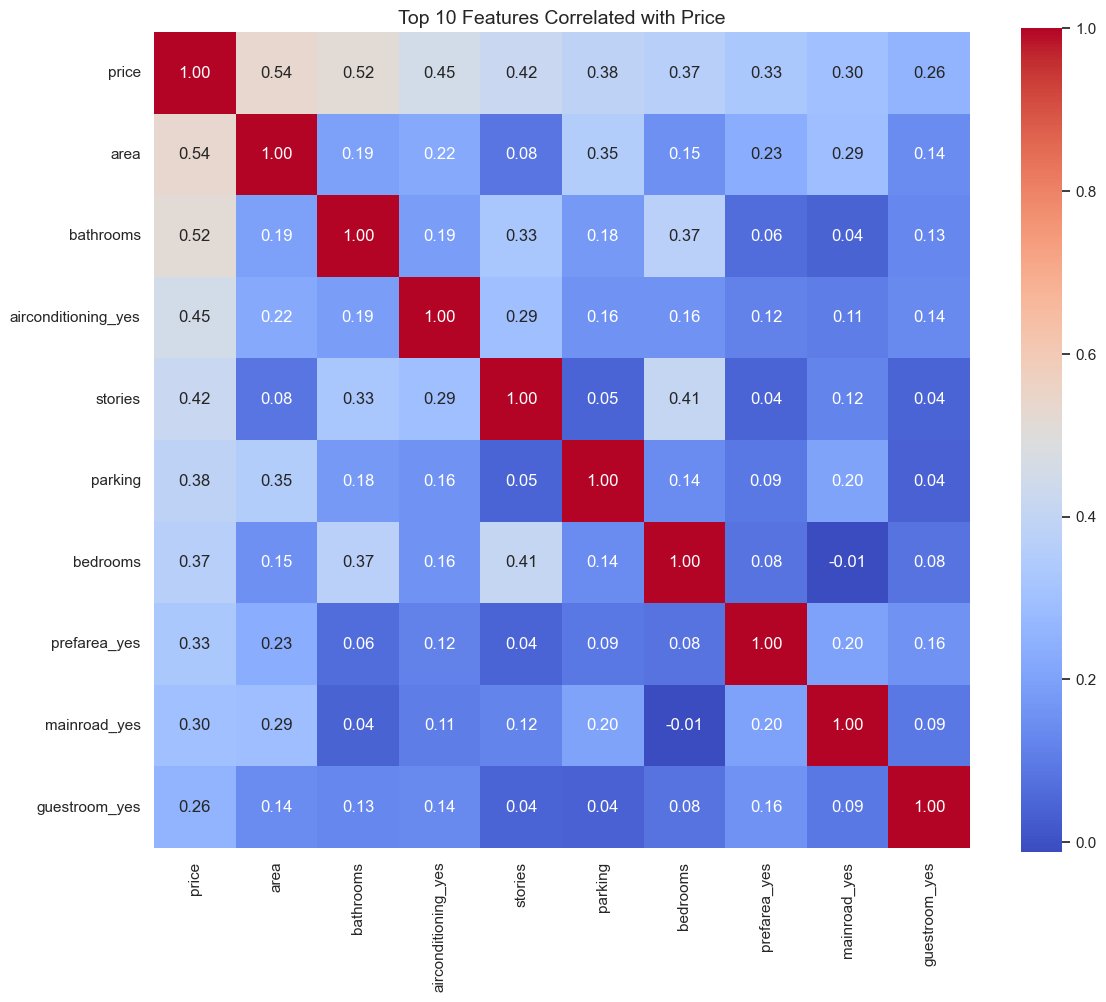

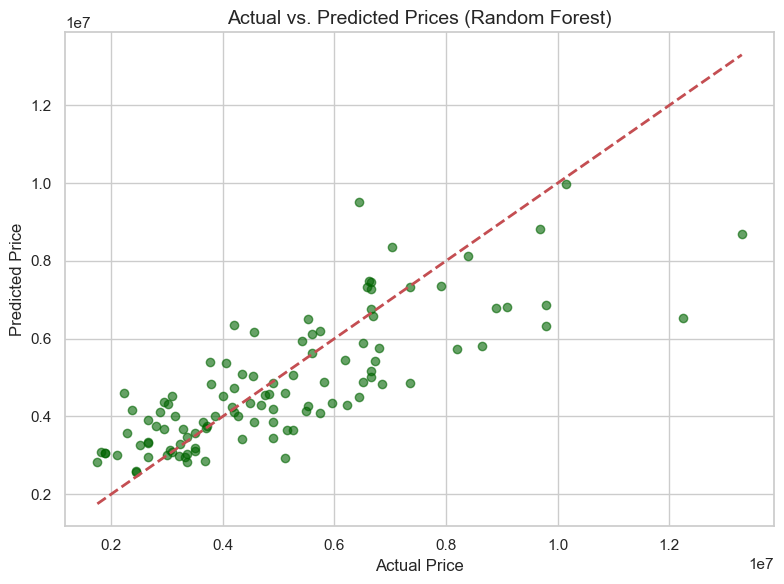

In [6]:
    # Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(10, 5))
sns.histplot(df_encoded['price'], kde=True, color='skyblue')
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price (in Millions)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('charts/price_distribution.png', dpi=300)
plt.show()

# Chart 2: Correlation Heatmap
plt.figure(figsize=(12, 10))
# Top 10 correlated features to keep the heatmap highly readable
top_corr_features = df_encoded.corr().nlargest(10, 'price')['price'].index
sns.heatmap(df_encoded[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Top 10 Features Correlated with Price', fontsize=14)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=300)
plt.show()

# Chart 3: Actual vs Predicted Price (Scatter Plot)
rf_preds = rf_model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices (Random Forest)', fontsize=14)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png', dpi=300)
plt.show()

Task 5 — Insights & Summary

Based on the exploratory data analysis, the features that influence house prices the most are the overall living area (correlation of 0.54) and the number of bathrooms (correlation of 0.52), followed closely by the presence of airconditioning (0.45). In plain terms, our baseline Linear Regression model was moderately accurate, capturing approximately 65.29% of the variance in housing prices ($R^2 = 0.6529$), outperforming the Random Forest Regressor ($R^2 = 0.6119$).A surprising trend in the dataset is that the absolute number of bedrooms carries a significantly weaker relationship to a house's value (0.37) than structural spaces like bathrooms or total multi-story layouts. Furthermore, the price distribution plot reveals a distinct right-skew, showcasing a concentrated market of affordable homes below $6 million alongside a sparse, trailing high-end luxury tier extending past $12 million.Business Recommendation: To optimize property valuations and maximize ROI, real estate developers and sellers should prioritize expanding layout square footage, modernizing bathroom facilities, and integrating air conditioning infrastructure over simply partitioning spaces to add extra bedrooms, as consumers heavily favor premium interior amenities and utility space over sheer bedroom counts.